# Configure Defaults

In [59]:
import os

MODELS_DIR = 'models/'
if not os.path.exists(MODELS_DIR):
    os.mkdir(MODELS_DIR)

MODEL_TF = MODELS_DIR + 'model.keras'
MODEL_NO_QUANT_TFLITE = MODELS_DIR + 'model_no_quant.tflite'
MODEL_QUANT_TFLITE = MODELS_DIR + 'model_quant.tflite'
MODEL_TFLITE_MICRO = MODELS_DIR + 'sine_model_quantized.cc'

# Setup Environment

Install Dependencies

In [7]:
! pip install tensorflow==2.4.0

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


Import Dependencies

In [32]:
# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

# Set seed for experimental reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

# Dataset

## 1. Generate Data

The following code generates a set of random x values, calculate their sine values, and displays the result on a graph.

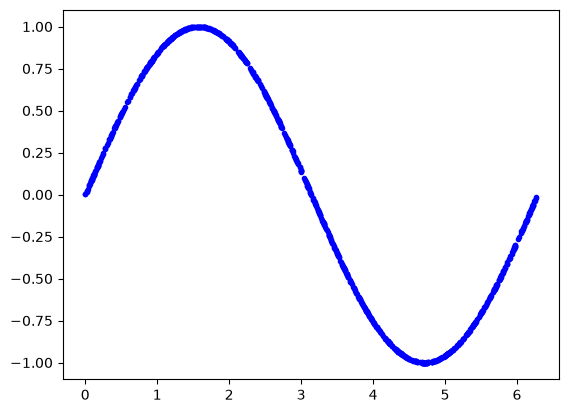

In [33]:
# How many data points we have
SAMPLES = 1000

# Generate uniformly distributed set of random numbers ranging from 0-2π (a complete sine oscillation), the numbers are 32-bit floats.
x_values = np.random.uniform(low = 0, high = 2*math.pi, size=SAMPLES).astype(np.float32)

# Shuffle the values to ensure that they are not in order
# deep learning training depends on data being in random order, otherwise it will be less accurate
np.random.shuffle(x_values)

# Calculate the corresponding y-values
y_values = np.sin(x_values).astype(np.float32)

# Plot the values ('b.' tells the library to print in blue (b) dots (.))
plt.plot(x_values, y_values, 'b.')
plt.show()

## 2. Add Noise

The data fits the sine way perfectly, which does not represent real world data.

Machine learning models are good at extracting meaning from messy data, to simulate this we add some noise to the data.

In the following cell, we'll add some random noise then draw a graph of the new data as compared to the old.

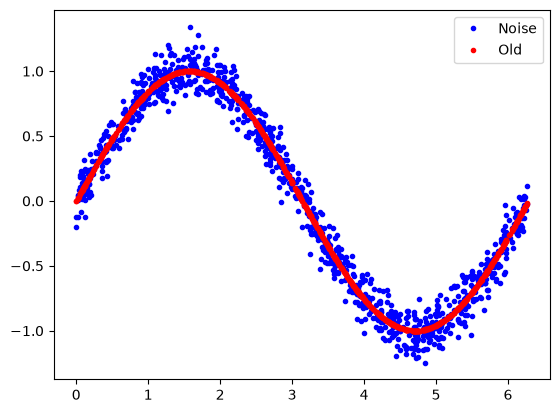

In [34]:
# Save old y_values
old_y_values = np.sin(x_values).astype(np.float32)

# Add ranodom y-offset
y_values += 0.1 * np.random.randn(*y_values.shape)

# Plot the data
plt.plot(x_values, y_values, 'b.', label='Noise')
plt.plot(x_values, old_y_values, 'r.', label='Old')
plt.legend()
plt.show()

## 3. Split The Data

We now have noisy data that approximates real world data. We will use this to train our model.

In order to evaluate accuracy we need to compare its predictions against real data and check how well they match. This will be done during training (called validation) and after training (referred to as testing). The data needs to be fresh.

The typical split is 60% for training, 20% for validation and 20% for testing.

We will use NumPy's ```split()``` method for this. It takes the array we want to split as well as an array of indices where we want the split to happen. The method returns a list of arrays for each split chunk.

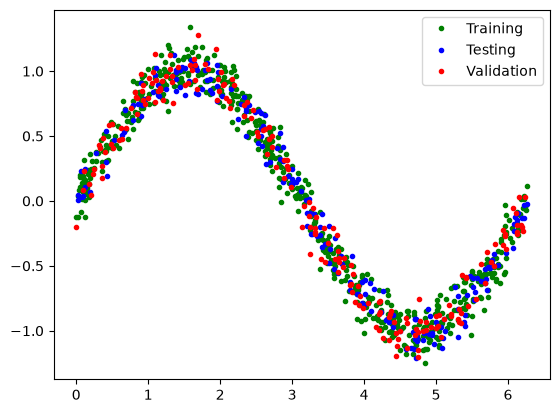

In [35]:
# 60% of the data will be used for training and 20% for testing. The remaining 20% will be used for validation.
TRAIN_SPLIT = int(0.6*SAMPLES)
TEST_SPLIT = int(0.2*SAMPLES + TRAIN_SPLIT)

# The data will be divided into three chunks as we provide 2 indices.
x_train, x_test, x_validate = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

# Plot each partition in different colors:
plt.plot(x_train, y_train, 'g.', label='Training')
plt.plot(x_test, y_test, 'b.', label='Testing')
plt.plot(x_validate, y_validate, 'r.', label='Validation')
plt.legend()
plt.show()

# Training

## 1. Design The Model

We will build a model that takes a numerical value `x` as input and gives a numerical value `y` as output (in this case the sine of `x`). This type of problem is called a _regression_. Regression models can also be used to predict a person's running speed based on data from an accelorometer for example.

For this problem we will start by creating a simple neural network consisting of 2 layers. The first layer will take an input `x` and runs it through 8 neurons. The neuron will then become _activated_ to a certain degree. The amount of activation for each neuron is based on its _weight_ and _bias_ values, learned during training, as well as its _activation function_. The activation is calculated as ```activation = activation_function((input * weight) + bias)```. The activation function we will use is called _rectified linear unit_, or ReLU for short. ReLU is defined as ```ReLU(x) = max(0, x)```. The reason we use an activation function is because without it the network could only model linear relationships where the ratio between `x` and `y` always stays the same. This would not work for this example as a sine wave is nonlinear.

The following cell defines the simple network model using Keras, TensorFlow's high-level API for creating deep-learning networks. The architecture that we will use will be `Sequential` meaning each layer will be stacked on top of the next. The first layer will have 8 neurons and 1 input, it will use ReLU as the activation function. The layer will be dense meaning that the input will be fed into every single one of its neurons during inference, when we're making predictions. The second layer will consist of a single neuron as we want the output to be a single value.

In [36]:
# We'll use Keras to create a simple model architecture
model_1 = tf.keras.Sequential(name='model_1')

# We first define the input shape. As we want a scalar value as input we define it as such
model_1.add(keras.layers.Input(shape=(1,)))

# The first layer consists of 8 neurons and the activation function is ReLU.
model_1.add(keras.layers.Dense(8, activation='relu', name="layer1"))

# Final layer is a single neuron
# Because this neuron has multiple inputs, it has corresponding weight values for each.
# The neurons outpus is calculated as:
# output = sum((inputs * weights)) + bias
# Where `inputs` and `weights` are NumPy arrays of 8 elements each
model_1.add(keras.layers.Dense(1, name="layer2"))

# Compile the model using the standard 'adam' optimizer and the mean squared error or 'mse' loss function for regression.
# The optimizer is the algorithm that will adjust the network to model its input during training, for this we will use 'adam'
# The loss is the method used during training to calculate how far the network's predictions are from reality, here we use the mean squared error (mse)
# which is a loss function used for regression problems.
# The metrics argument allows us to specify additional arguments that may be used to judge the performance of our model. We specify mae or `mean abso-
# lute error`, which is a helpful function for measuring the perfomance of a regression model.
model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

From the results shown by `model_1.summary()` we can see some information about our model. We can see each layer and its output shape as well as how many parameters each layer has as well as in total. The size of a network - how much memory space it takes up - mostly depends on the amount of parameters, which are weights and biases. For a simple model like ours the amount of weights can be calculated as the number of connections between neurons, given that each connection has a weight. From the summary above we can see that `layer1` has 16 parameters, this is because it is dense meaning that each neuron is connected to the scalar input which results in 1 weight for each giving 8 total weights. This in addition to each neurons bias gives us 8 + 8 = 16 paramaters. The second layer has one weight for each neuron from the first layer in addition to its bias giving 8 + 1 = 9 paramaters. So in total we get 16 + 9 = 25 parameters.

## 2. Training Our Model

Now that we have defined our model it is time to _train_ it. Training involves passing a new `x` value into the neural network, checking how far the network's output deviates from the expected `y` value using the specified loss method, and adjusting the neurons' weights and biases using the specified optimizer algorithm so that the output is more likely to be correct the next time (minimize the loss value). Go ahead and run the code cell under this before continuing to read as it can take some time.

To train our model we will use the `fit()` function. Let's look at the arguments that the function takes:
> `x_train`, `y_train`
>> The first two arguments for `fit()` are the x and y values of our training data. In our case this will be `x_train` and `y_train` defined earlier.

> `epochs`
>> Specifies how many times the entire training set will be run through during the networks training. The more epochs the more training. Too much training can lead to overfitting, we will also see that the model will stop improving after a certain amount of epochs. We will start with `500` epochs of training.

> `batch_size`
>> Specifies how many pieces of training data to feed into the network before measuring the accuracy and updating its weights and biases. If we specify a `batch_size` of `1` we'd run inference on a single datapoint, measure the loss and update the networks weights and biases. Because we have 600 datapoints for training this would result in 600 updates per epoch, which is a lot of computation and would take ages. A `batch_size` of `600` would mean only 1 update for each epoch which would lead to overfitting. We will choose a `batch_size` of `64`, but it is best to choose a `batch_size` of `16` or `32` and experiment to see what works best for your scenario.

> `validation_data`
>> Specifies our validation dataset. This data will be run through the network throughout the training process, and the network's predictions will be compared with the expected values, the results of this will be part of the object returned by the `fit()` function. Our validation data has been defined as `x_validate` and `y_validate` earlier.

In [37]:
history_1 = model_1.fit(x_train, y_train, epochs=500, batch_size=64, validation_data=(x_validate, y_validate))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.7257 - mae: 1.2165 - val_loss: 1.4987 - val_mae: 1.1302
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3431 - mae: 1.0584 - val_loss: 1.1583 - val_mae: 0.9735
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0353 - mae: 0.9077 - val_loss: 0.8940 - val_mae: 0.8269
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8007 - mae: 0.7689 - val_loss: 0.6993 - val_mae: 0.6991
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6307 - mae: 0.6529 - val_loss: 0.5632 - val_mae: 0.6052
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5136 - mae: 0.5760 - val_loss: 0.4730 - val_mae: 0.5540
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4369 - mae: 0.5316 - val_loss: 0.4163 - val_mae: 0.5292
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3893 - mae: 0.5066 - val_loss: 0.3826 - val_mae: 0.5188
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.36

## 3. Checking Training Metrics

Wait until training has completed before reading on.

We will now check various metrics to see how well our network has learned. First we will compare the last written log with the first from the cell above. The first output shows something like:

`loss: 1.7257 - mae: 1.2165 - val_loss: 1.4987 - val_mae: 1.1302`

And the last something like:

`loss: 0.1482 - mae: 0.3122 - val_loss: 0.1686 - val_mae: 0.3356`

A quick glance show us that the network has improved as the loss has decreased, but lets go through each metric individually:

> `loss`
>> The output of our loss function, we're using mean squared error which is expressed as a positive number where a lower value is better. Our ouput shows a drop from ~1.7 to ~0.15 which clearly shows that the network has improved.

> `mae`
>> This is the mean absolute error of our training data. It shows the average difference between the network's predictions and the expected `y` values from our training data. We can expect that the initial `mae` is pretty dismal as it is based on an untrained network. This is certainly the case as the network is off by an average of ~1.2, which is a huge number when you consider that the range of acceptable values are only from -1 to 1! <br> However, after training it has dropped to ~0.30 which is better but still quite awful.

> `val_loss`
>> This is the output from the loss function on our validation data. The final output shows that `val_loss` (~0.17) is slightly higher than the training loss (`loss: 0.15`). This is a hint that our network might be overfitting, because it is performing worse on data it has not seen before.

> `val_mae`
>> This is the mean absolute error for our validation data. Here we also see that the score is worse than the training `mae` (`val_mae` > `mae`). AAnother sign that the network might be overfitting.

### Plotting The Training Metrics

**1. Loss (or Mean Squared Error)**

During training, the model's perfomance is constantly being measured against both our training and validation data. This is logged in the `history_1` object that we set aside earlier. The next cell will show this data in graphical form, in order to find out why our network is underperforming.

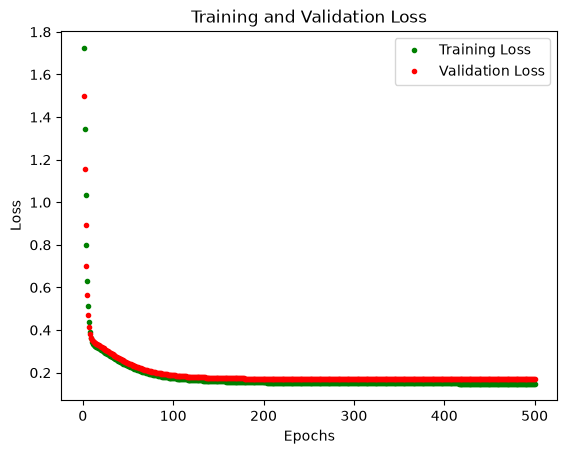

In [38]:
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training Loss')
plt.plot(epochs, val_loss, 'r.', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

As we can see the loss rapidly decreases over the first few epochs which makes the rest of the graph and the part that is important difficult to see, as we want to stop training the model when it is no longer improving. The next cell will skip the first few epochs in order to make the rest of the graph easier to see.

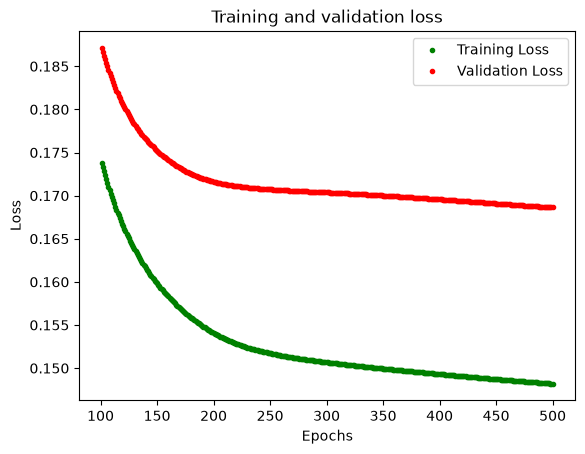

In [41]:
SKIP = 100

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training Loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'r.', label='Validation Loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

From the plot, we can see that the loss continues to decrease up until around `200` epochs, at which point it is mostly stable. This means that there is no point in training our model beyond `200` epochs.

However, you can also see that the lowest loss value is still around 0.15. This seems relatively high. In addition the `val_loss` values are consistently even higher. To gain more insight, lets plot our mean absolute error.

**2. Mean Absolute Error**

The following cell will plot our model's mean absolute error for both the training and validation data.

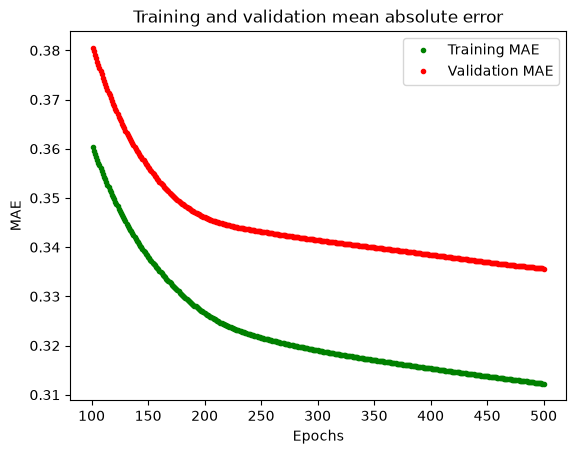

In [42]:
mae = history_1.history['mae']
val_mae = history_1.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'r.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

This plot gives us further clues. We can see that the `training MAE` is consistetly lower than the `validation MAE`, which might indicate that the network is overfitting. In addition the `MAE` values are quite high, around 0.31-0.32, which means our model is off by at least 0.31. Since our expected values range from -1 to 1, an error of ~0.31 means we are very far away from the expected result (at least 31% off).

To get further insight we can plot the network's predictions for the training data against the expected values. This happens in the following cell.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


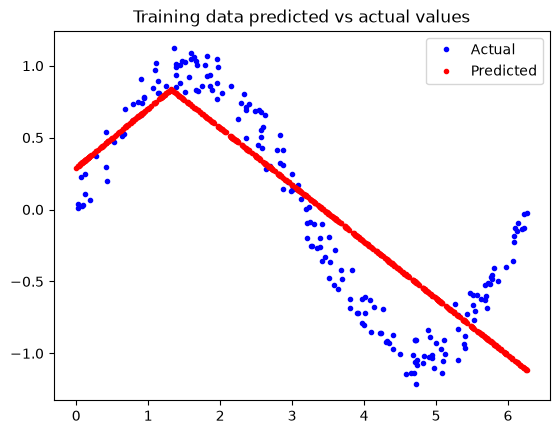

In [43]:
# Run inference on all x values from the training data. This returns an array of predictions.
predictions = model_1.predict(x_train)

# Plot the expected data along side the predicted data.
plt.clf()
plt.title('Training data predicted vs actual values')
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_train, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()

This looks bad. The graph makes it clear that the network does a poor job in approximating the sine function. The prediction is extremely linear, and only very roughly follows the data.

The rigidity suggests that the model does not have enough capacity to learn the complexity of the sine wave function, it is therefore only able to approximate it in a very rough way. This has a simple solution, make the model bigger.

# Improving The Model

## 1. Design The Model

To make our model bigger, let's add an additional layer of neurons as well as increasing the number of neurons in the first layer. The following cell does just that.

In [45]:
model_improved = tf.keras.Sequential()

# Increase the first layer to 16 neurons
model_improved.add(keras.layers.Input(shape=(1,)))
model_improved.add(keras.layers.Dense(16, activation='relu', name='input_layer'))

# Add a new layer
model_improved.add(keras.layers.Dense(16, activation='relu', name='hidden_layer'))

# Output layer
model_improved.add(keras.layers.Dense(1, name='output_layer'))

# Compile the model
model_improved.compile(optimizer='adam', loss="mse", metrics=["mae"])

# Summary
model_improved.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

With an additional layer and double the amount of neurons the size of our model has increased by a lot. We went from `25` parameters and `100B` to `321` parameters and `1.25KB`. The input layer has `16` weights, each neuron in the second layer has `1` weight for each neuron in the first layer so in total we get `16*16 = 256` weights, and the output layer has `1` weight for each neuron in the second layer which is `16` weights. In total we have `16+16+1 = 33` biases and so the amount of parameters add to `16 + 16 + 256 + 33 = 321 parameters`.

## 2. Train The Model

We will now train the model and save it to disk.

In [48]:
history_improved = model_improved.fit(x_train, y_train, epochs=500, batch_size=64, validation_data=(x_validate, y_validate))

# Save the model to disk
model_improved.save(MODEL_TF)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0135 - mae: 0.0932 - val_loss: 0.0135 - val_mae: 0.0925
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0135 - mae: 0.0931 - val_loss: 0.0134 - val_mae: 0.0923
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0135 - mae: 0.0930 - val_loss: 0.0134 - val_mae: 0.0922
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - mae: 0.0930 - val_loss: 0.0133 - val_mae: 0.0921
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - mae: 0.0929 - val_loss: 0.0133 - val_mae: 0.0919
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - mae: 0.0928 - val_loss: 0.0133 - val_mae: 0.0918
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - mae: 0.0927 - val_loss: 0.0133 - val_mae: 0.0916
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0133 - mae: 0.0927 - val_loss: 0.0132 - val_mae: 0.0915
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.013

This shows a huge improvement from the previous model. The loss has dropped from ~0.15 to ~0.01, and the mean absolute error has dropped from ~0.32 to ~0.09. Lets plot some graphs to see how it's going.

## 3. Plot Metrics

The following cell will print the same graphs we used to evaluate our original model, but showing our new training history.

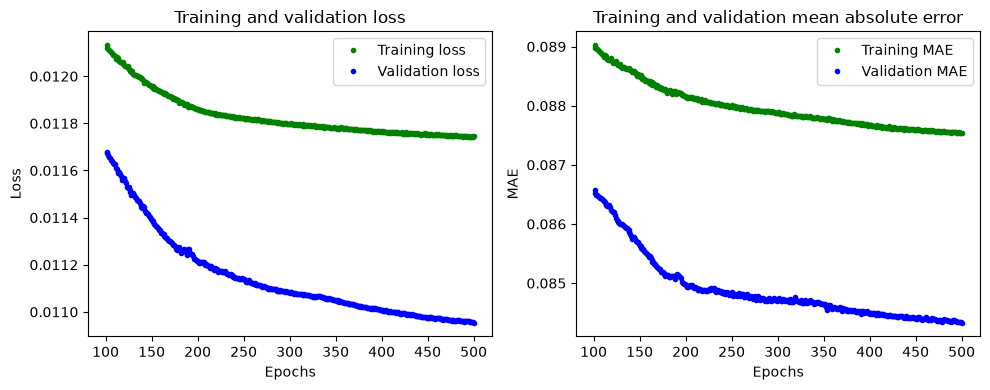

In [49]:
train_loss = history_improved.history['loss']
val_loss = history_improved.history['val_loss']

epochs = range(1, len(train_loss)+1)

SKIP = 100

plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)

plt.plot(epochs[SKIP:], train_loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)



train_mae = history_improved.history['mae']
val_mae = history_improved.history['val_mae']

plt.plot(epochs[SKIP:], train_mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()

These are great results!

We can see that the overall loss and MAE is much lower than it was before. We can also see that the network is no longer overfitting, as the validation metrics are better than the training metrics. The reason that the validation metrics are better and not equal to the training metrics is because the validation metrics are calculated at the end of each epoch, meanwhile the training metrics are calculated during the epoch. This means that the validation metrics are done on a more trained model. Lets run a final test to see how well our model performs with completely new data.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - mae: 0.0808 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


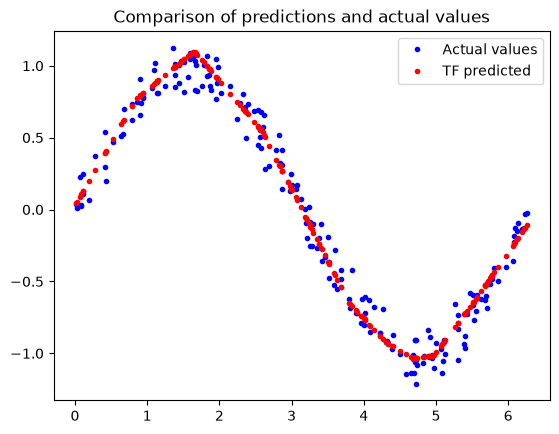

In [51]:
# Calculate loss and MAE on our test data to see how far the predicitions deviate from the actual values
test_loss, test_mae = model_improved.evaluate(x_test, y_test)

# Make predictions on our test dataset
predictions = model_improved.predict(x_test)

# Plot the predictions alongside the actual values
plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(x_test, y_test, 'b.', label='Actual values')
plt.plot(x_test, predictions, 'r.', label='TF predicted')
plt.legend()
plt.show()

From this we can see that, for the most part, the _predicted_ values form a smooth sine-like curve along the center of distribution of the _actual_ values. The model has in other words approximated a sine way using noisy data!

# Generate a TensorFlow Lite Model

TensorFlow Lite is a set of tools for running TensorFlow models on edge devices, such as phones or microcontrollers. We will think of it as having 2 main components:

> _TensorFlow Lite Converter_
>> Converts TensorFlow models into a space-efficient format for use on memory-constrained devices. It can also perform further optimizations that further reduce the model size and make it run faster on smaller devices.

> _TensorFlow Lite Interpreter_
>> This runs an appropriately converted TensorFlow Lite model using the most efficient operations for a given device.

To convert the model we will use the TensorFlow Lite Converter's Python API. It will take our Keras model and write it to disk in the form of a _FlatBuffer_, which is a special file format designed to be space efficient.

The converter can also apply optimizations to the model. These optimizations can reduce the size, the time it takes to run, or both. This may come at the cost of some accuracy but the reduction is often small enough to be worthwhile. 

One useful optimization is called _quantization_. By default the biases and weights of the model are stores as 32-bit floating-point numbers to allow for high-precision calculations during training. Quantization allows you to reduce the precision to fit in 8-bit integers. This is a 4x reduction in size, and because CPUs can work faster with integers than floats, a quantized model will run faster. Quantization often result in minimal loss in accuracy, so when deploying on low-memory devices, it is nearly always worth it.

In the following cell we will convert and save 2 new versions of our improved model, the first will not be quanized, the second will be quantized.

In [54]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model_improved)
model_no_quant_tflite = converter.convert()

# Save to disk
open(MODEL_NO_QUANT_TFLITE, "wb").write(model_no_quant_tflite)

# Convert the model to TensorFlow Lite format with quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Yields a set of numbers that represent the full range of input values on which the model was trained
def representative_dataset_generator():
    for i in range(500):
        yield([x_train[i].reshape(1,1)])

# Enfore integer only quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Provide representative dataset to ensure we quantize correctly
converter.representative_dataset = representative_dataset_generator
model_quant_tflite = converter.convert()

# Save model to disk
open(MODEL_QUANT_TFLITE, "wb").write(model_quant_tflite)

INFO:tensorflow:Assets written to: /tmp/tmpr0sege1p/assets


INFO:tensorflow:Assets written to: /tmp/tmpr0sege1p/assets


Saved artifact at '/tmp/tmpr0sege1p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_30')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139764230384256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139764230389056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139764230388096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273561536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273560096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273559616: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1782393044.508848   75367 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782393044.508872   75367 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782393044.509250   75367 reader.cc:83] Reading SavedModel from: /tmp/tmpr0sege1p
I0000 00:00:1782393044.509834   75367 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782393044.509845   75367 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpr0sege1p
I0000 00:00:1782393044.514429   75367 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782393044.515089   75367 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782393044.545101   75367 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpr0sege1p
I0000 00:00:1782393044.554017   75367 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 44788 microseconds.
I0000 00:00:1782393044.570269   75367

INFO:tensorflow:Assets written to: /tmp/tmp1_qh0sst/assets


INFO:tensorflow:Assets written to: /tmp/tmp1_qh0sst/assets


Saved artifact at '/tmp/tmp1_qh0sst'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_30')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139764230384256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139764230389056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139764230388096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273561536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273560096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139763273559616: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/lib/python3.14/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782393045.040051   75367 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782393045.040073   75367 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782393045.040246   75367 reader.cc:83] Reading SavedModel from: /tmp/tmp1_qh0sst
I0000 00:00:1782393045.040649   75367 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782393045.040655   75367 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp1_qh0sst
I0000 00:00:1782393045.044760   75367 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782393045.070731   75367 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp1_qh0sst
I0000 00:00:1782393045.079137   75367 loader.cc:471] SavedModel load for tags { serve }; Status: suc

3936

We now need to check that these models are still accurate after conversion and quantization. We use both to make predictions and compare them against our test results. Because we are using TensorFlow Lite we need to use the interpreter to do so. With Keras we could call the `predict` method, but because TensorFlow Lite is designed to be efficient it is slightly more complicated. We will need to instantiate an `Interpreter` object, allocate memory for the model, write input to the input tensor, invoke the model and finally read the output from the output tensor.

We do this in the following cell.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/lib/python3.14/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


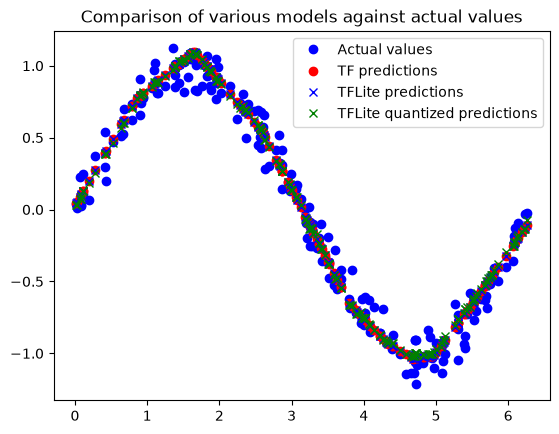

In [56]:
def predict_tflite(tflite_model, x_test):
    # Prepare the test data
    x_test_ = x_test.copy()
    x_test_ = x_test_.reshape((x_test.size, 1))
    x_test_ = x_test_.astype(np.float32)

    # Init the TFLite Interpreter
    interpreter = tf.lite.Interpreter(model_content=tflite_model, experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF)

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # If required, quantize the input layer (from float to integer)
    input_scale, input_zero_point = input_details["quantization"]
    if (input_scale, input_zero_point) != (0.0, 0):
        x_test_ = x_test_ / input_scale + input_zero_point
        x_test_ = x_test_.astype(input_details["dtype"])
    
    # Invoke the interpreter
    y_pred = []
    for i in range(len(x_test_)):
        interpreter.set_tensor(input_details["index"], [x_test_[i]])
        interpreter.invoke()
        y_pred.append(interpreter.get_tensor(output_details["index"])[0])
    
    # If required, dequantize the output layer (from integer to float)
    output_scale, output_zero_point = output_details["quantization"]
    if (output_scale, output_zero_point) != (0.0, 0):
        y_pred = y_pred.astype(np.float32)
        y_pred = (y_pred - output_zero_point) * output_scale
    
    return y_pred


# Calculate predictions
y_test_pred_tf = model_improved.predict(x_test)
y_test_pred_no_quant_tflite = predict_tflite(model_no_quant_tflite, x_test)
y_test_pred_quant_tflite = predict_tflite(model_quant_tflite, x_test)

# See how prediction lines up with data
plt.clf()
plt.title('Comparison of various models against actual values')
plt.plot(x_test, y_test, 'bo', label='Actual values')
plt.plot(x_test, y_test_pred_tf, 'ro', label='TF predictions')
plt.plot(x_test, y_test_pred_no_quant_tflite, 'bx', label='TFLite predictions')
plt.plot(x_test, y_test_pred_quant_tflite, 'gx', label='TFLite quantized predictions')
plt.legend()
plt.show()

We can see from the graph that the predictions of the original model, the converted model and the quantized model are close enough to be indistinguishable. Since we did this to reduce the size of the models, lets check the differences in size.

In [57]:
size_tf = os.path.getsize(MODEL_TF)
size_no_quant_tflite = os.path.getsize(MODEL_NO_QUANT_TFLITE)
size_quant_tflite = os.path.getsize(MODEL_QUANT_TFLITE)

# Compare the size
pd.DataFrame.from_records(
    [
        ["TensorFlow", f"{size_tf} bytes", ""],
        ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
        ["TensorFlow Lite Quantized", f"{size_quant_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_quant_tflite} bytes)"]
    ],
    columns=["Model", "Size", ""], index="Model"
)

,Size,
Model,,
TensorFlow,29377 bytes,
TensorFlow Lite,3364 bytes,(reduced by 26013 bytes)
TensorFlow Lite Quantized,3936 bytes,(reduced by -572 bytes)


# Converting to C file

The final step in getting our model ready for a Microcontroller is to convert it into a C source file that can be included in our application. So far we have used the TensorFlow Lite interpreter to load the model from disk. But most microcontrollers do not have a filesystem, and the time it takes to load from disk would be wasteful. The solution is to provide our model in a C source file that can be included in our binary and loaded directly into memory.

In the file, the model is defined as an array of bytes. Fortunately, there's a convenient tool in Unix called `xxd` that can be used to convert a file to a desired format.

The following cell runs `xxd` on our quantized model and writes the result to a file called `sine_model_quantized.cc`, it then prints the result to screen.

In [62]:
# Install xxd if it is not available
! apt-get update && apt-get -qq install xxd

# Save the file as a C source file
! xxd -i {MODEL_QUANT_TFLITE} > {MODEL_TFLITE_MICRO}

# Update variable names using sed
REPLACE_TEXT = MODEL_QUANT_TFLITE.replace('/', '_').replace('.', '_')
! sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

# Print the source file
! cat {MODEL_TFLITE_MICRO}

zsh:1: command not found: apt-get
unsigned char g_model[] = {
  0x20, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x00, 0x00, 0x00, 0x00,
  0x14, 0x00, 0x20, 0x00, 0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00,
  0x0c, 0x00, 0x00, 0x00, 0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00,
  0x1c, 0x00, 0x00, 0x00, 0x8c, 0x00, 0x00, 0x00, 0xe4, 0x00, 0x00, 0x00,
  0xb8, 0x03, 0x00, 0x00, 0xc8, 0x03, 0x00, 0x00, 0xd4, 0x0e, 0x00, 0x00,
  0x03, 0x00, 0x00, 0x00, 0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00,
  0xf6, 0xfb, 0xff, 0xff, 0x0c, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,
  0x3c, 0x00, 0x00, 0x00, 0x0f, 0x00, 0x00, 0x00, 0x73, 0x65, 0x72, 0x76,
  0x69, 0x6e, 0x67, 0x5f, 0x64, 0x65, 0x66, 0x61, 0x75, 0x6c, 0x74, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x90, 0xff, 0xff, 0xff,
  0x0b, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 0x08, 0x00, 0x00, 0x00,
  0x6f, 0x75, 0x74, 0x70, 0x75, 0x74, 0x5f, 0x30, 0x00, 0x00, 0x00, 0x00,
  0x01, 0x00, 0x00, 0x00, 0x04, 0x00, 0x00, 0x00, 

We now have a C source file for our model that can be used for the next Lab!